# Ejercicio 9: Generación de mapas predictivos

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import joblib

from src.config import OUT_DIR

plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42

## 9.0 Carga de datos, modelo y conjunto de prueba

Se reconstruyen las mismas variables (`FEATURES`, `TARGET`) que en los Ejercicios 4-6, se carga el modelo XGBoost ya entrenado, y se recupera el conjunto de prueba original usando `split_train_test.parquet` para no recalcular una partición distinta.

In [2]:
df = pd.read_parquet(OUT_DIR / "ml_dataset.parquet")

UMBRAL_ALTA_CIANOBACTERIA = 10.0
df["alta_cianobacteria"] = (df["cianobacteria"] > UMBRAL_ALTA_CIANOBACTERIA).astype(int)

dia_anio = df["fecha"].dt.dayofyear
df["dia_anio_sin"] = np.sin(2 * np.pi * dia_anio / 365)
df["dia_anio_cos"] = np.cos(2 * np.pi * dia_anio / 365)
df["ndvi_x_ndwi"] = df["ndvi"] * df["ndwi"]

NUM_FEATURES = ["green", "nir", "ndvi", "ndwi", "lat", "lon",
                 "dia_anio_sin", "dia_anio_cos", "ndvi_x_ndwi"]
CAT_FEATURES = ["lago"]
FEATURES = NUM_FEATURES + CAT_FEATURES
TARGET = "alta_cianobacteria"

MODELOS_DIR = OUT_DIR / "modelos"
mejor_modelo = joblib.load(MODELOS_DIR / "modelo_xgb.joblib")

split_info = pd.read_parquet(OUT_DIR / "split_train_test.parquet").set_index("idx_original")
idx_test = split_info.index[split_info["particion"] == "test"]

print(f"Observaciones en el conjunto de prueba: {len(idx_test):,} "
      f"({len(idx_test) / len(df):.1%} del total)")

C:\Users\isabe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator OneHotEncoder from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\isabe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator FunctionTransformer from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\isa

Observaciones en el conjunto de prueba: 161,603 (30.0% del total)


C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\pickle.py:1718: UserWarning: [18:05:36] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)
C:\Users\isabe\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Pipeline from version 1.9.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more

## 9.1. Probabilidad de alta presencia de cianobacteria por observación

In [4]:
columnas_extra = [c for c in ["fecha", "x_utm", "y_utm"] if c in df.columns]

todas_columnas = list(dict.fromkeys(columnas_extra + FEATURES + [TARGET]))
df_test = df.loc[idx_test, todas_columnas].copy()

df_test["proba"] = mejor_modelo.predict_proba(df_test[FEATURES])[:, 1]
df_test["pred"] = (df_test["proba"] >= 0.5).astype(int)
df_test = df_test.rename(columns={TARGET: "real"})

print(f"Probabilidad calculada para {len(df_test):,} observaciones del conjunto de prueba.")
df_test[["lago", "fecha", "lat", "lon", "real", "proba", "pred"]].head()

Probabilidad calculada para 161,603 observaciones del conjunto de prueba.


,lago,fecha,lat,lon,real,proba,pred
idx_original,,,,,,,
247457,atitlan,2026-02-12,14.712597,-91.184516,1,0.596487,1
155920,atitlan,2025-07-17,14.642974,-91.238929,0,0.016788,0
86721,atitlan,2025-05-13,14.686218,-91.162916,0,0.000195,0
342037,atitlan,2026-04-13,14.704879,-91.179938,0,0.000503,0
218897,atitlan,2025-12-29,14.688289,-91.139225,0,0.023633,0


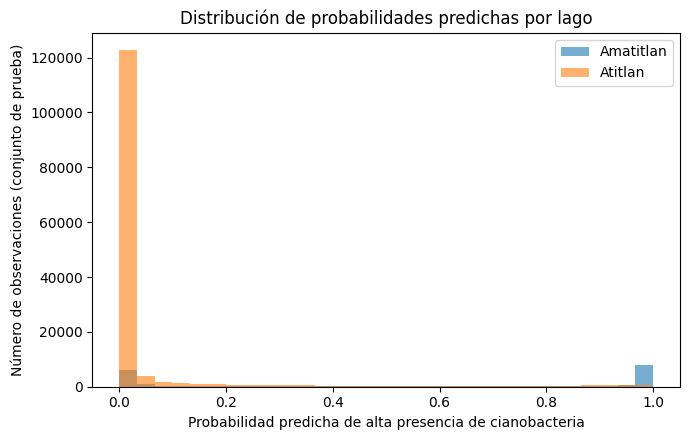

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))
for lago, sub in df_test.groupby("lago", observed=True):
    ax.hist(sub["proba"], bins=30, alpha=0.6, label=lago.capitalize())
ax.set_xlabel("Probabilidad predicha de alta presencia de cianobacteria")
ax.set_ylabel("Número de observaciones (conjunto de prueba)")
ax.set_title("Distribución de probabilidades predichas por lago")
ax.legend()
plt.tight_layout()
plt.show()

## 9.2 a 9.4. Reconstrucción espacial y mapas de probabilidad

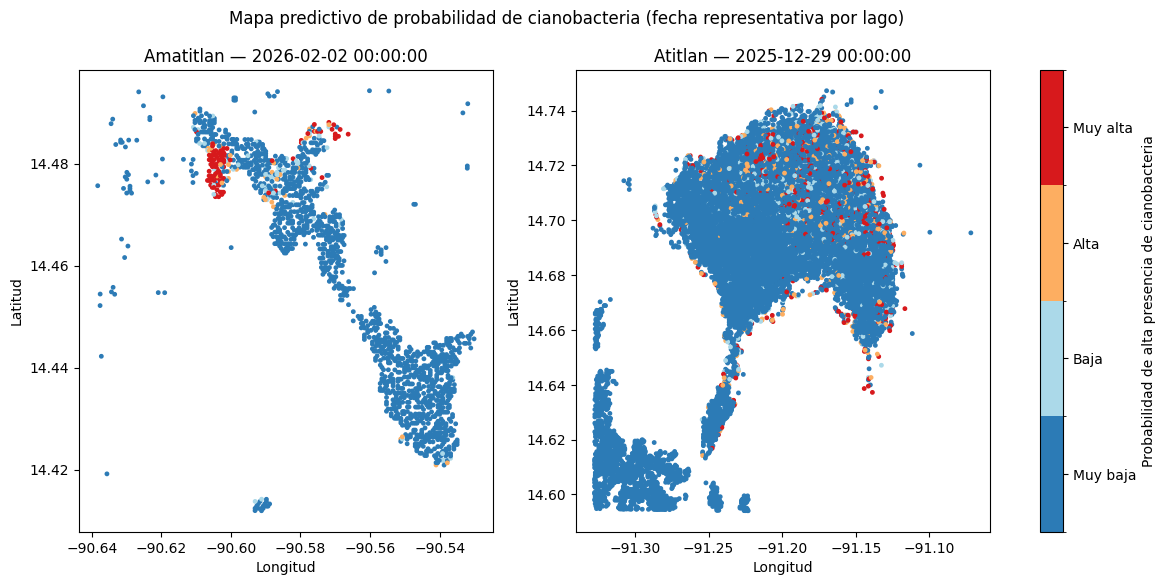

In [6]:
BINS_PROBA = [0.0, 0.25, 0.5, 0.75, 1.0]
ETIQUETAS_PROBA = ["Muy baja", "Baja", "Alta", "Muy alta"]
COLORES_PROBA = ["#2c7bb6", "#abd9e9", "#fdae61", "#d7191c"]

cmap_proba = mcolors.ListedColormap(COLORES_PROBA)
norm_proba = mcolors.BoundaryNorm(BINS_PROBA, cmap_proba.N)


def mapa_probabilidad(data, lago, fecha=None, ax=None):
    """Dibuja un mapa de probabilidad de alta presencia de cianobacteria
    para un lago (y opcionalmente una fecha específica) usando lon/lat."""
    sub = data[data["lago"] == lago]
    if fecha is not None:
        sub = sub[sub["fecha"] == pd.Timestamp(fecha)]

    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 6))

    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["proba"],
                     cmap=cmap_proba, norm=norm_proba, s=6)
    ax.set_title(f"{lago.capitalize()}" + (f" — {fecha}" if fecha else " (todas las fechas de prueba)"))
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    return sc


# Fecha representativa por lago (la mediana de las fechas presentes en el conjunto de prueba)
fechas_test_por_lago = {
    lago: sorted(sub["fecha"].unique())[len(sub["fecha"].unique()) // 2]
    for lago, sub in df_test.groupby("lago", observed=True)
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, (lago, fecha) in zip(axes, fechas_test_por_lago.items()):
    sc = mapa_probabilidad(df_test, lago, fecha, ax=ax)

cbar = fig.colorbar(sc, ax=axes, ticks=[0.125, 0.375, 0.625, 0.875], fraction=0.046)
cbar.ax.set_yticklabels(ETIQUETAS_PROBA)
cbar.set_label("Probabilidad de alta presencia de cianobacteria")
fig.suptitle("Mapa predictivo de probabilidad de cianobacteria (fecha representativa por lago)")
plt.show()

**Interpretación (9.2-9.4):** en Amatitlán, la probabilidad "muy alta" se concentra en un clúster compacto y bien definido en la zona noroeste del lago, con un segundo grupo más disperso de puntos "alta"/"muy alta" hacia el norte. En Atitlán, la probabilidad predicha es "muy baja" en la inmensa mayoría del lago, con puntos "alta"/"muy alta" dispersos principalmente en el borde del lago (zonas costeras), consistente con que las floraciones tienden a acumularse donde hay menor circulación de agua y mayor cercanía a fuentes de nutrientes.

## 9.5. Comparación con los mapas de cianobacteria de la Parte I

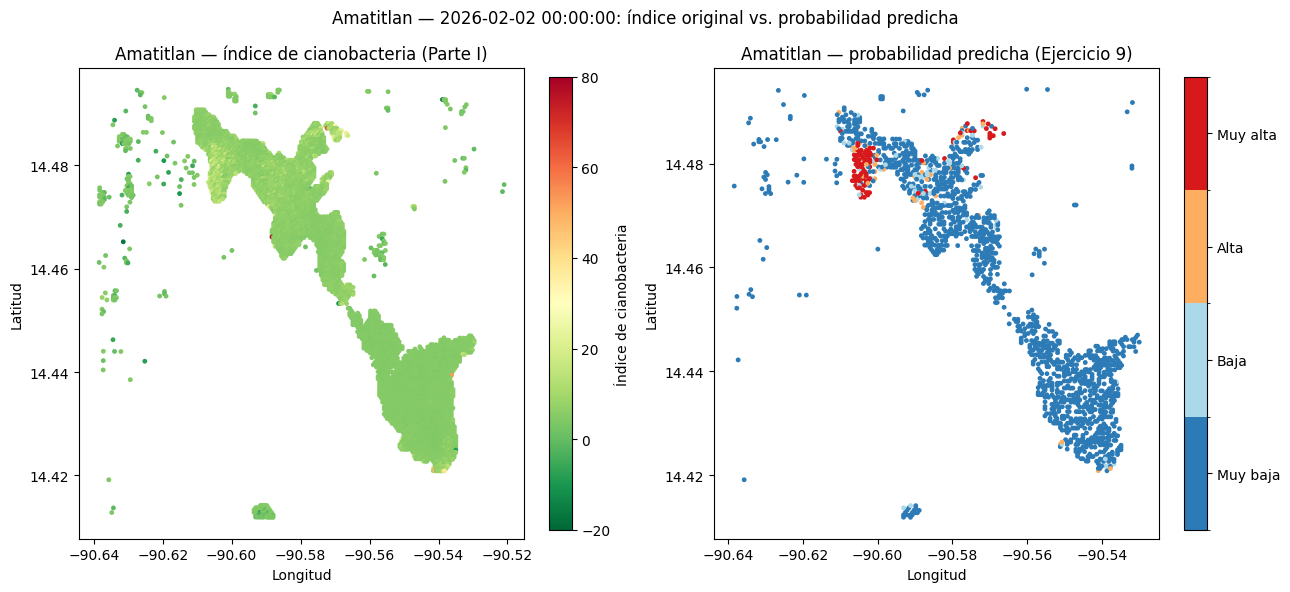

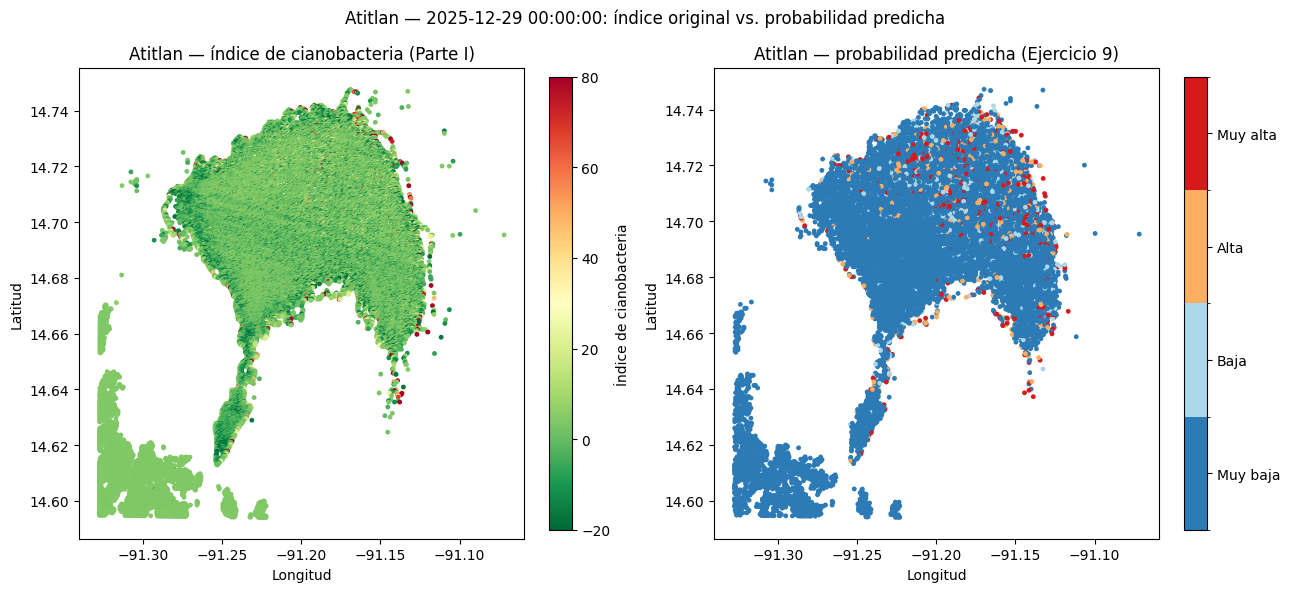

In [7]:
for lago, fecha in fechas_test_por_lago.items():
    sub_original = df[(df["lago"] == lago) & (df["fecha"] == pd.Timestamp(fecha))]
    sub_pred = df_test[(df_test["lago"] == lago) & (df_test["fecha"] == pd.Timestamp(fecha))]

    fig, axes = plt.subplots(1, 2, figsize=(13, 6))

    sc0 = axes[0].scatter(sub_original["lon"], sub_original["lat"],
                           c=sub_original["cianobacteria"], cmap="RdYlGn_r",
                           vmin=-20, vmax=80, s=6)
    axes[0].set_title(f"{lago.capitalize()} — índice de cianobacteria (Parte I)")
    fig.colorbar(sc0, ax=axes[0], fraction=0.046, label="Índice de cianobacteria")

    sc1 = axes[1].scatter(sub_pred["lon"], sub_pred["lat"], c=sub_pred["proba"],
                           cmap=cmap_proba, norm=norm_proba, s=6)
    axes[1].set_title(f"{lago.capitalize()} — probabilidad predicha (Ejercicio 9)")
    cbar1 = fig.colorbar(sc1, ax=axes[1], ticks=[0.125, 0.375, 0.625, 0.875], fraction=0.046)
    cbar1.ax.set_yticklabels(ETIQUETAS_PROBA)

    for ax in axes:
        ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")

    fig.suptitle(f"{lago.capitalize()} — {fecha}: índice original vs. probabilidad predicha")
    plt.tight_layout()
    plt.show()

**Interpretación (9.5):** Sí, coinciden. En Amatitlán, el clúster de probabilidad "muy alta" predicha (mapa derecho) se encuentra justo en la misma zona noroeste donde el índice de cianobacteria original (mapa izquierdo) presenta sus valores más altos (tonos naranja/rojo). En Atitlán, ambos mapas muestran que la mayor parte del lago tiene valores bajos o muy bajos, con algunas excepciones de valores altos concentradas en el borde del lago. Esto indica que el modelo logró captar bastante bien el patrón espacial real y no simplemente el promedio general de cada lago.

## 9.6. Zonas correctamente detectadas, falsos positivos y falsos negativos

Se clasifica cada observación de prueba en una de 4 categorías según la combinación de valor real y valor predicho (umbral 0.5), y se visualiza espacialmente. Se usan todas las fechas del conjunto de prueba para tener una vista más completa de los patrones de error.

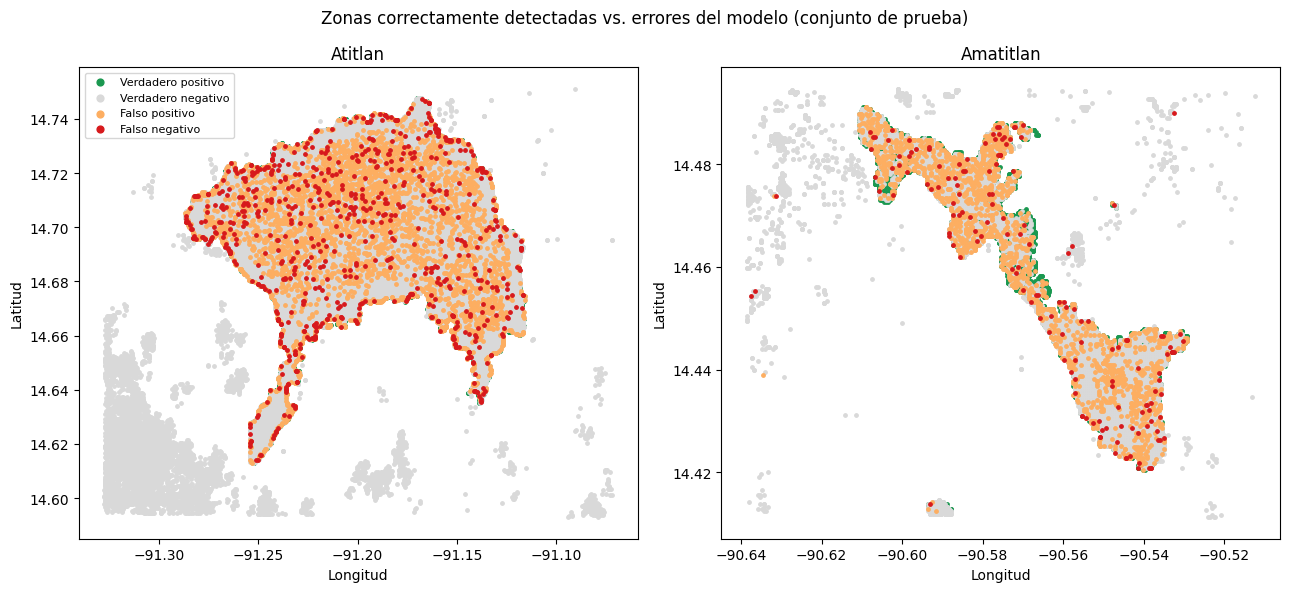

Distribución de categorías de error por lago:


categoria_error,Falso negativo,Falso positivo,Verdadero negativo,Verdadero positivo
amatitlan,0.008,0.087,0.462,0.443
atitlan,0.005,0.026,0.952,0.017


In [9]:
def categoria_error(row):
    if row["real"] == 1 and row["pred"] == 1:
        return "Verdadero positivo"
    if row["real"] == 0 and row["pred"] == 0:
        return "Verdadero negativo"
    if row["real"] == 0 and row["pred"] == 1:
        return "Falso positivo"
    return "Falso negativo"


df_test["categoria_error"] = df_test.apply(categoria_error, axis=1)

colores_error = {
    "Verdadero positivo": "#1a9850",
    "Verdadero negativo": "#d9d9d9",
    "Falso positivo": "#fdae61",
    "Falso negativo": "#d7191c",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = df_test[df_test["lago"] == lago]
    for categoria, color in colores_error.items():
        parte = sub[sub["categoria_error"] == categoria]
        ax.scatter(parte["lon"], parte["lat"], c=color, s=6, label=categoria)
    ax.set_title(lago.capitalize())
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")

axes[0].legend(loc="upper left", fontsize=8, markerscale=2)
fig.suptitle("Zonas correctamente detectadas vs. errores del modelo (conjunto de prueba)")
plt.tight_layout()
plt.show()

print("Distribución de categorías de error por lago:")
display(pd.crosstab(df_test["lago"], df_test["categoria_error"], normalize="index").round(3).rename_axis(None))

**Interpretación (9.6):** los dos lagos tienen un comportamiento muy distinto, ligado a su tasa base de positivos reales. Amatitlán tiene una proporción de positivos reales mucho más alta (~45%), consistente con ser un lago históricamente más eutrofizado. Ahí el modelo detecta bien los positivos (44.3%) pero también genera más falsos positivos, lo cual tiene sentido. Donde hay más señal real de
floración, las zonas de transición entre "alta" y "baja" presencia son más ambiguas para el modelo. En Atitlán casi no hay positivos reales (~2.2% en total) y el modelo acierta la gran mayoría de las observaciones (95.2%), con una tasa de falsos positivos baja (2.6%). En el mapa, Atitlán se ve con "muchos" puntos naranja simplemente porque tiene muchas más observaciones de prueba, no porque su error proporcional sea mayor.

## 9.7. Dificultad sistemática por región (usando los bloques del Ejercicio 6)

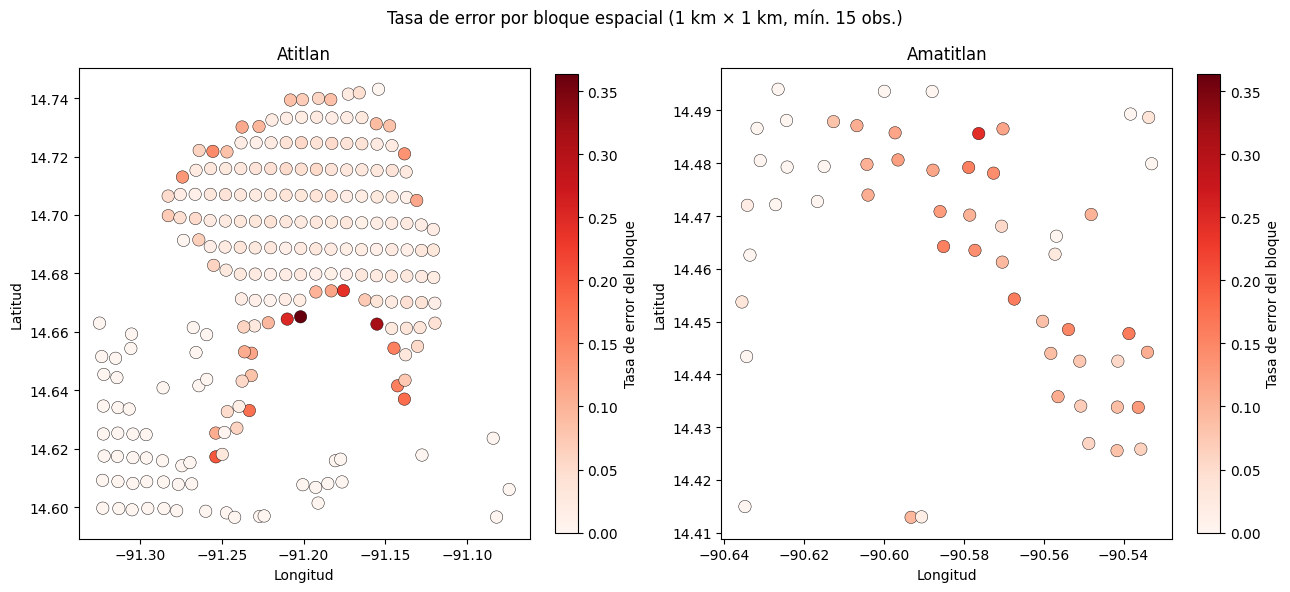

Bloques con mayor tasa de error (top 10):


,lago,bloque_id,n_obs,tasa_error
146,atitlan,atitlan_13_7,44,0.363636
211,atitlan,atitlan_18_7,263,0.315589
133,atitlan,atitlan_12_7,135,0.251852
69,amatitlan,amatitlan_6_8,299,0.244147
189,atitlan,atitlan_16_8,79,0.240506
348,atitlan,atitlan_7_2,70,0.200000
245,atitlan,atitlan_20_4,45,0.177778
109,atitlan,atitlan_10_4,125,0.176000
11,amatitlan,amatitlan_10_4,43,0.162791
71,amatitlan,amatitlan_7_4,381,0.160105


In [11]:
BLOQUE_SIZE_M = 1000

def asignar_bloques(data, size=BLOQUE_SIZE_M):
    bloques = pd.Series(index=data.index, dtype=object)
    for lago, idx in data.groupby("lago", observed=True).groups.items():
        sub = data.loc[idx]
        col = np.floor((sub["x_utm"] - sub["x_utm"].min()) / size).astype(int)
        fila = np.floor((sub["y_utm"] - sub["y_utm"].min()) / size).astype(int)
        bloques.loc[idx] = lago + "_" + col.astype(str) + "_" + fila.astype(str)
    return bloques


df_test["bloque_id"] = asignar_bloques(df_test)
df_test["error"] = (df_test["pred"] != df_test["real"]).astype(int)

MIN_OBS_POR_BLOQUE = 15  # evita conclusiones sobre bloques con muy pocas observaciones

tasa_error_bloque = (
    df_test.groupby(["lago", "bloque_id"], observed=True)
    .agg(n_obs=("error", "size"), tasa_error=("error", "mean"),
         x_utm=("x_utm", "mean"), y_utm=("y_utm", "mean"),
         lon=("lon", "mean"), lat=("lat", "mean"))
    .reset_index()
)
tasa_error_bloque = tasa_error_bloque[tasa_error_bloque["n_obs"] >= MIN_OBS_POR_BLOQUE]

fig, axes = plt.subplots(1, 2, figsize=(13, 6))
for ax, lago in zip(axes, ["atitlan", "amatitlan"]):
    sub = tasa_error_bloque[tasa_error_bloque["lago"] == lago]
    sc = ax.scatter(sub["lon"], sub["lat"], c=sub["tasa_error"],
                     cmap="Reds", vmin=0, vmax=tasa_error_bloque["tasa_error"].max(),
                     s=80, edgecolor="k", linewidth=0.3)
    ax.set_title(lago.capitalize())
    ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
    fig.colorbar(sc, ax=ax, fraction=0.046, label="Tasa de error del bloque")

fig.suptitle(f"Tasa de error por bloque espacial (1 km × 1 km, mín. {MIN_OBS_POR_BLOQUE} obs.)")
plt.tight_layout()
plt.show()

print("Bloques con mayor tasa de error (top 10):")
tasa_error_bloque.sort_values("tasa_error", ascending=False).head(10)[
    ["lago", "bloque_id", "n_obs", "tasa_error"]
]

**Interpretación (9.7):** Sí existen regiones con dificultad sistemática, y se concentran mayoritariamente en Atitlán. 7 de los 10 bloques con mayor tasa de error pertenecen a ese lago (hasta 36% de error en el bloque `atitlan_13_7`, y 32% en `atitlan_18_7`), frente a un máximo de 24% en Amatitlán (`amatitlan_6_8`). 

Los bloques con mayor error en Atitlán se ubican en la zona sur-suroeste del lago. Una hipótesis razonable es que esas zonas son de transición agua-tierra donde el NDWI puede ser ambiguo (píxeles mixtos), lo que dificulta que el modelo distinga correctamente la clase. Otra posibilidad es que, al tener pocos positivos reales en Atitlán en general, cualquier floración puntual real en esos bloques se comporta casi como un caso atípico que el modelo no logra generalizar bien con tan poca representación en entrenamiento.